<a href="https://colab.research.google.com/github/elsarsa/esktraksi-fitur-citra-lombok/blob/main/2418018KlasifikasiCitraCabaiMetodeKNN%2Cipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from google.colab import drive
import os

# Load Dataset


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/dataset_lombok/dataset_cabai.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat!")
else:
    print("File tidak ditemukan!")

df.head()

Mounted at /content/drive
Dataset berhasil dimuat!


,Foto,H,S,V,Kontras,Korelasi,Energi,Homogenitas,Area,Perimeter,Metric
0,23.jpg,98.897525,18.166825,159.890425,26.564397,0.989308,0.063592,0.622703,33017.5,714.409161,healthy
1,21.jpg,126.754175,17.843050,185.673900,25.884925,0.991286,0.064820,0.612621,36543.5,752.953317,healthy
2,20.jpg,97.742275,12.505525,158.900050,27.617462,0.991110,0.064985,0.612231,33078.5,711.923880,healthy
3,25.jpg,126.916875,18.912450,120.448775,44.099698,0.987989,0.063875,0.721194,20707.0,826.499559,healthy
4,13.jpg,102.114425,13.041750,187.271725,24.159623,0.993551,0.066973,0.619882,36907.5,759.438599,healthy


# Eksplorasi Data




In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.columns)
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Foto         100 non-null    object 
 1   H            100 non-null    float64
 2   S            100 non-null    float64
 3   V            100 non-null    float64
 4   Kontras      100 non-null    float64
 5   Korelasi     100 non-null    float64
 6   Energi       100 non-null    float64
 7   Homogenitas  100 non-null    float64
 8   Area         100 non-null    float64
 9   Perimeter    100 non-null    float64
 10  Metric       100 non-null    object 
dtypes: float64(9), object(2)
memory usage: 8.7+ KB
None
                H           S           V     Kontras    Korelasi      Energi  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean   117.892246   15.503226  148.256438   38.368858    0.988878    0.059067   
std     17.007580    2.852057   20.791631   22.083

# Visualisasi Data

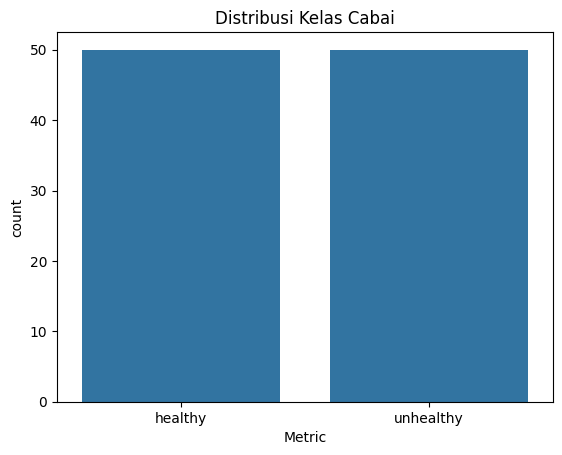

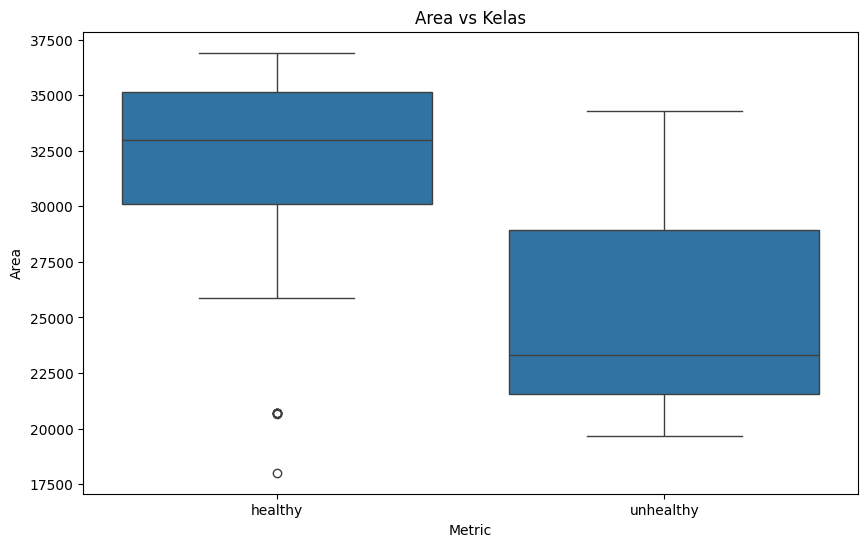

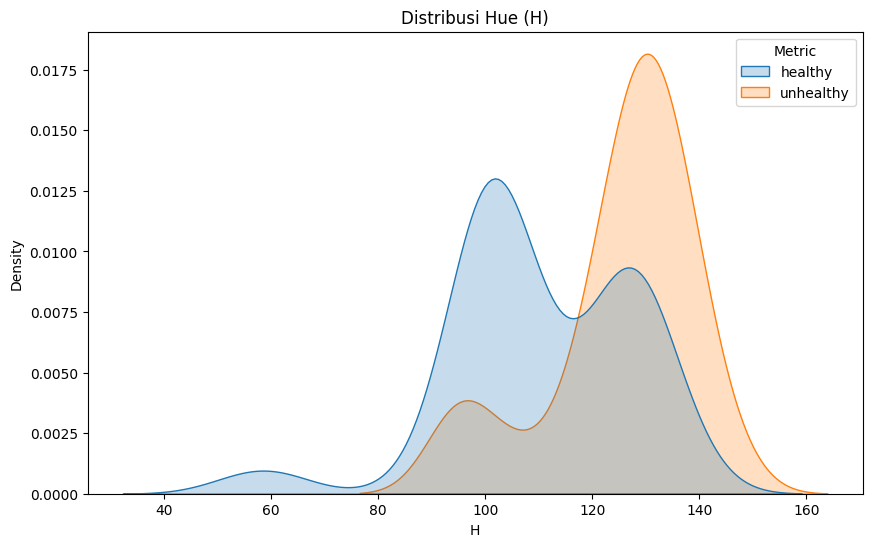

In [ ]:
# Distribusi kelas
sns.countplot(x='Metric', data=df)
plt.title('Distribusi Kelas Cabai')
plt.show()

# Analisis Area
plt.figure(figsize=(10,6))
sns.boxplot(x='Metric', y='Area', data=df)
plt.title('Area vs Kelas')
plt.show()

# Distribusi HSV
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='H', hue='Metric', fill=True)
plt.title('Distribusi Hue (H)')
plt.show()

# Preprocessing


In [ ]:
# Rename biar rapi
df = df.rename(columns={'Metric': 'label'})

# Pisahkan fitur & target
X = df.drop(columns=['Foto', 'label'])
Y = df['label']

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Data


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42)

# Model Knn

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

KNeighborsClassifier()

# Evaluasi



In [ ]:
y_pred = knn.predict(X_test)

print("Akurasi:", accuracy_score(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

Akurasi: 0.85
              precision    recall  f1-score   support

     healthy       0.91      0.83      0.87        12
   unhealthy       0.78      0.88      0.82         8

    accuracy                           0.85        20
   macro avg       0.84      0.85      0.85        20
weighted avg       0.86      0.85      0.85        20



# Confussion Matrix


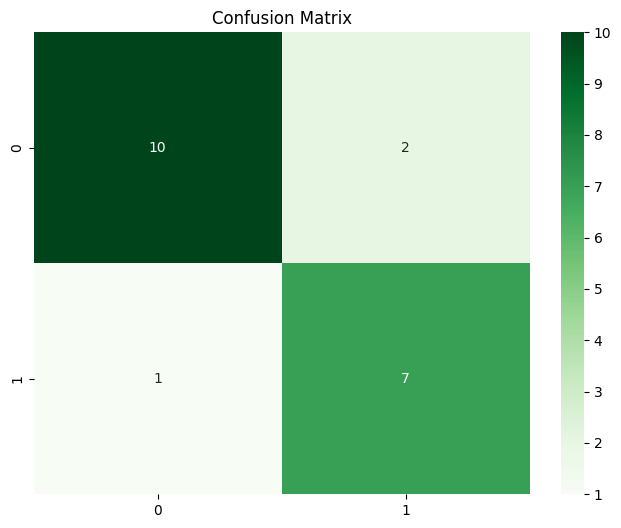

In [ ]:
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.show()

# Uji K

In [ ]:
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    print(f"K={k}, Akurasi={accuracy_score(Y_test, pred):.2%}")

K=1, Akurasi=100.00%
K=2, Akurasi=90.00%
K=3, Akurasi=90.00%
K=4, Akurasi=90.00%
K=5, Akurasi=85.00%
K=6, Akurasi=95.00%
K=7, Akurasi=95.00%
K=8, Akurasi=95.00%
K=9, Akurasi=95.00%
K=10, Akurasi=95.00%
